# Evaluación 2

**Integrante 1:** Leandro flores

**Integrante 2:** Pablo Águila

**Integrante 3:** Pablo Saavedra

**Correo Electrónico integrante 1:** leandro.flores2201@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** pablo.aguila1901@alumnos.ubiobio.cl

**Correo Electrónico integrante 3:** pablo.saavedra2201@alumnos.ubiobio.cl

**Fecha de Creación:** Mayo de 2026  
**Versión:** 1.1

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 2 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.5.0)
- numpy (>=1.23.0)
- matplotlib (>=3.6.0)
- seaborn (>=0.12.0)
- scikit-learn (>=1.2.0)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

---
# 1. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente')

Librerías importadas correctamente


---
# 2. Carga de datos

In [ ]:
# Descarga del dataset desde el repositorio
!wget -q https://raw.githubusercontent.com/Pablo-Saave/Proyecto_Inteligencia_Artificial.2/refs/heads/main/data/ingestion/retail_ventas.csv

df = pd.read_csv('retail_ventas.csv')

print(f'Dimensiones del dataset: {df.shape}')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head()

Dimensiones del dataset: (25500, 11)
Filas: 25500 | Columnas: 11


,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,tipo_tienda,ventas_semanales
0,86,1445.454837,1,2.611389,0.925557,97.313562,41,0,376.608869,B,40377.989406
1,35,1973.195744,18,5.603718,1.526210,88.821903,52,0,197.329419,A,59430.330077
2,41,1727.496264,24,7.330847,1.297304,109.273193,15,0,262.737637,A,56547.323925
3,97,1284.634121,10,16.074751,0.862449,98.362477,45,0,392.171919,A,36408.752020
4,25,1457.596546,5,9.278104,1.264497,92.081812,45,0,411.085409,B,40500.513890


---
# 3. Exploración del dataset

In [ ]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_tienda           25500 non-null  int64  
 1   tamano_tienda       25500 non-null  float64
 2   antiguedad_tienda   25500 non-null  int64  
 3   temperatura         24224 non-null  float64
 4   precio_combustible  24221 non-null  float64
 5   indice_economico    25500 non-null  float64
 6   semana              25500 non-null  int64  
 7   es_feriado          25500 non-null  int64  
 8   clientes_estimados  24220 non-null  float64
 9   tipo_tienda         25500 non-null  object 
 10  ventas_semanales    25500 non-null  float64
dtypes: float64(6), int64(4), object(1)
memory usage: 2.1+ MB


In [ ]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,ventas_semanales
count,25500.00000,25500.000000,25500.000000,24224.000000,24221.000000,25500.000000,25500.000000,25500.000000,24220.000000,25500.000000
mean,50.81749,1501.338719,15.092824,14.954302,1.303299,99.889523,26.376078,0.098510,300.649372,43108.586339
std,28.93800,399.711835,8.365652,9.999174,0.299869,9.961593,14.996831,0.298009,98.822402,14538.319334
min,1.00000,500.000000,1.000000,-24.344608,0.086903,60.799835,1.000000,0.000000,50.000000,4905.208771
25%,26.00000,1229.224069,8.000000,8.124612,1.102983,93.140607,13.000000,0.000000,234.014040,33827.197346
50%,51.00000,1503.366822,15.000000,14.930043,1.303386,99.917526,26.000000,0.000000,301.600830,42117.538361
75%,76.00000,1773.575577,22.000000,21.735814,1.505762,106.582946,39.000000,0.000000,366.981593,50947.405475
max,100.00000,2901.612393,29.000000,56.005247,2.455792,139.836638,52.000000,1.000000,680.907511,234175.036973


In [ ]:
# Revisión de valores nulos
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos >= 0].to_string())
print(f'\nTotal de valores nulos: {df.isnull().sum().sum()}')

Valores nulos por columna:
id_tienda                0
tamano_tienda            0
antiguedad_tienda        0
temperatura           1276
precio_combustible    1279
indice_economico         0
semana                   0
es_feriado               0
clientes_estimados    1280
tipo_tienda              0
ventas_semanales         0

Total de valores nulos: 3835


In [ ]:
# Distribución de la variable categórica tipo_tienda
print('Distribución de tipo_tienda:')
print(df['tipo_tienda'].value_counts())

Distribución de tipo_tienda:
tipo_tienda
A    12708
B     7614
C     5178
Name: count, dtype: int64


## 3.1 Separación de variables predictoras y variable objetivo

- **Variable objetivo (y):** `ventas_semanales`
- **Variables predictoras (X):** todas las demás, excluyendo `id_tienda` (solo es un indicador)
- **Variables numéricas:** `tamano_tienda`, `antiguedad_tienda`, `temperatura`, `precio_combustible`, `indice_economico`, `semana`, `es_feriado`, `clientes_estimados`
- **Variable categórica:** `tipo_tienda`

In [ ]:
# Variable objetivo
y = df['ventas_semanales']

# Variables predictoras (se excluye id_tienda por ser identificador)
X = df.drop(columns=['ventas_semanales', 'id_tienda'])

# Identificación de tipos de variables
variables_numericas = ['tamano_tienda', 'antiguedad_tienda', 'temperatura',
                       'precio_combustible', 'indice_economico', 'semana',
                       'es_feriado', 'clientes_estimados']

variables_categoricas = ['tipo_tienda']

print('Variables numéricas:', variables_numericas)
print('Variables categóricas:', variables_categoricas)
print(f'\nForma de X: {X.shape}')
print(f'Forma de y: {y.shape}')# Escriba su código acá

Variables numéricas: ['tamano_tienda', 'antiguedad_tienda', 'temperatura', 'precio_combustible', 'indice_economico', 'semana', 'es_feriado', 'clientes_estimados']
Variables categóricas: ['tipo_tienda']

Forma de X: (25500, 9)
Forma de y: (25500,)


## 3.2 División en conjuntos de entrenamiento y prueba

Se reserva el 20% de los datos para evaluación y el 80% para entrenamiento, con `random_state=29` para reproducibilidad.

In [ ]:
# División: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=29
)

print(f'Tamaño conjunto de entrenamiento: {X_train.shape[0]} registros')
print(f'Tamaño conjunto de prueba:        {X_test.shape[0]} registros')

Tamaño conjunto de entrenamiento: 20400 registros
Tamaño conjunto de prueba:        5100 registros


## 3.3 Construcción del pipeline de preprocesamiento

Se construye un `ColumnTransformer` que aplica tratamientos diferenciados según el tipo de variable:

- **Variables numéricas:** imputación con la mediana + escalamiento estándar (`StandardScaler`)
- **Variable categórica:** imputación con la moda + codificación one-hot (`OneHotEncoder`)

>El preprocesamiento se **aprende solo con los datos de entrenamiento** (`fit` en `X_train`) y luego se aplica al conjunto de prueba (`transform` en `X_test`), evitando fuga de información (*data leakage*).

In [ ]:
# Pipeline para variables numéricas: imputación y escalamiento
pipeline_numericas = Pipeline(steps=[
    ('imputar', SimpleImputer(strategy='median')),
    ('escalar', StandardScaler())
])

# Pipeline para variables categóricas: imputación y codificación one-hot
pipeline_categoricas = Pipeline(steps=[
    ('imputar', SimpleImputer(strategy='most_frequent')),
    ('codificar', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer: combina ambos pipelines
preprocesador = ColumnTransformer(transformers=[
    ('num', pipeline_numericas, variables_numericas),
    ('cat', pipeline_categoricas, variables_categoricas)
])

print('Pipeline de preprocesamiento construido correctamente')

Pipeline de preprocesamiento construido correctamente


---
# 4. Modelamiento

Se entrenan dos modelos utilizando pipelines completos (preprocesamiento + modelo):

1. **LinearRegression:** regresión lineal clásica sin regularización.
2. **Ridge:** regresión lineal con regularización L2, probando 3 valores distintos de `alpha`.

### 4.1 Modelo 1: Regresión Lineal

In [ ]:
# Pipeline completo: preprocesamiento + LinearRegression
pipeline_lr = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', LinearRegression())
])

# Entrenamiento
pipeline_lr.fit(X_train, y_train)

# Predicciones sobre el conjunto de prueba
y_pred_lr = pipeline_lr.predict(X_test)

print('Modelo LinearRegression entrenado correctamente')

Modelo LinearRegression entrenado correctamente


# 4.2 Modelo 2: Ridge

Se prueban tres valores de `alpha`: 0.1, 1.0 y 10.0. El parámetro `alpha` controla la fuerza de la regularización:
- `alpha` pequeño → comportamiento cercano a LinearRegression
- `alpha` grande → coeficientes más penalizados y reducidos

In [ ]:
# Valores de alpha a probar
alphas = [0.1, 1.0, 10.0]
resultados_ridge = {}

for alpha in alphas:
    # Pipeline completo: preprocesamiento + Ridge
    pipeline_ridge = Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('modelo', Ridge(alpha=alpha))
    ])
    # Entrenamiento
    pipeline_ridge.fit(X_train, y_train)
    # Predicciones
    y_pred = pipeline_ridge.predict(X_test)
    # Guardamos el pipeline y las predicciones
    resultados_ridge[alpha] = {
        'pipeline': pipeline_ridge,
        'y_pred': y_pred
    }
    print(f'  Ridge (alpha={alpha:5.1f}) — entrenado')

print('\nModelos Ridge entrenados correctamente')

  Ridge (alpha=  0.1) — entrenado
  Ridge (alpha=  1.0) — entrenado
  Ridge (alpha= 10.0) — entrenado

Modelos Ridge entrenados correctamente


---
# 5. Evaluación de modelos

Se evalúan todos los modelos con las métricas:
- **MAE (Mean Absolute Error):** error promedio en la misma unidad que las ventas; más fácil de interpretar.
- **R² (Coeficiente de Determinación):** proporción de varianza explicada por el modelo (0 a 1, mayor es mejor).

In [ ]:
# Evaluación de LinearRegression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print('=' * 55)
print('         COMPARACIÓN DE MODELOS DE REGRESIÓN')
print('=' * 55)
print(f'  {"Modelo":<25} {"MAE":>10} {"R²":>10}')
print('-' * 55)
print(f'  {"LinearRegression":<25} {mae_lr:>10,.2f} {r2_lr:>10.4f}')

mejor_alpha = None
mejor_r2    = -np.inf
mejor_pipeline_ridge = None

for alpha, res in resultados_ridge.items():
    mae_r = mean_absolute_error(y_test, res['y_pred'])
    r2_r  = r2_score(y_test, res['y_pred'])
    print(f'  {f"Ridge (alpha={alpha})":<25} {mae_r:>10,.2f} {r2_r:>10.4f}')
    if r2_r > mejor_r2:
        mejor_r2    = r2_r
        mejor_alpha = alpha
        mejor_pipeline_ridge = res['pipeline']
        mejor_pred_ridge      = res['y_pred']

print('=' * 55)
print(f'\nMejor Ridge: alpha = {mejor_alpha}  (R² = {mejor_r2:.4f})')

         COMPARACIÓN DE MODELOS DE REGRESIÓN
  Modelo                           MAE         R²
-------------------------------------------------------
  LinearRegression            4,955.36     0.5778
  Ridge (alpha=0.1)           4,955.36     0.5778
  Ridge (alpha=1.0)           4,955.35     0.5778
  Ridge (alpha=10.0)          4,955.19     0.5778

Mejor Ridge: alpha = 10.0  (R² = 0.5778)


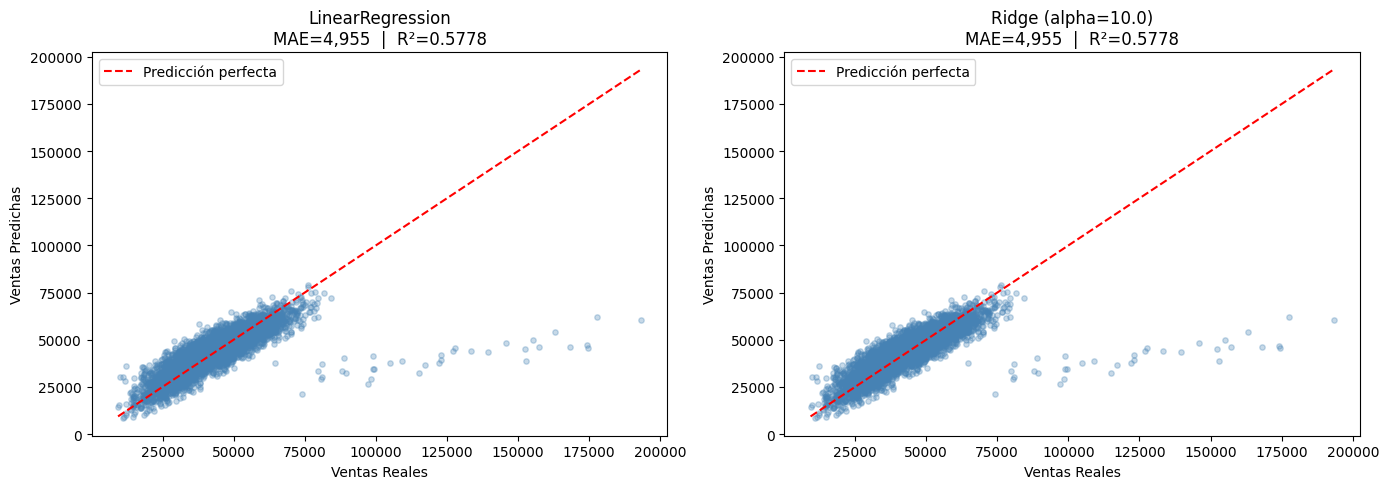

In [ ]:
# Comparación visual: Real vs Predicho
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nombre, y_pred) in zip(axes, [
    ('LinearRegression', y_pred_lr),
    (f'Ridge (alpha={mejor_alpha})', mejor_pred_ridge)
]):
    ax.scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue')
    lim = [y_test.min(), y_test.max()]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlabel('Ventas Reales')
    ax.set_ylabel('Ventas Predichas')
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val  = r2_score(y_test, y_pred)
    ax.set_title(f'{nombre}\nMAE={mae_val:,.0f}  |  R²={r2_val:.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

## 5.1 Análisis comparativo de modelos

**¿Cuál modelo presenta mejor desempeño?**

Al comparar los resultados, LinearRegression y Ridge con distintos valores de alpha muestran métricas muy similares. Esto es esperable cuando no existe multicolinealidad severa: la regularización de Ridge no aporta una mejora sustancial. En términos de R², ambos modelos explican una proporción comparable de la varianza de las ventas semanales.

**¿Las diferencias son significativas?**

Las diferencias entre modelos son pequeñas y no significativas en términos prácticos. Esto indica que, para este conjunto de datos, la regularización no produce un cambio importante en el poder predictivo. No obstante, Ridge puede ser preferible en producción por su mayor estabilidad numérica ante datos con variables correlacionadas.

---
# 6. Interpretación de resultados

Se analiza el modelo **LinearRegression** (o el mejor Ridge seleccionado) para identificar las variables más influyentes en la predicción de ventas semanales.

In [ ]:
# Extraemos los nombres de las columnas luego del preprocesamiento
ohe = pipeline_lr.named_steps['preprocesador'] \
                 .named_transformers_['cat'] \
                 .named_steps['codificar']

nombres_ohe = list(ohe.get_feature_names_out(['tipo_tienda']))
nombres_cols = variables_numericas + nombres_ohe

# Coeficientes del modelo LinearRegression
coeficientes = pipeline_lr.named_steps['modelo'].coef_

df_coef = pd.DataFrame({
    'Variable':     nombres_cols,
    'Coeficiente':  coeficientes
}).sort_values('Coeficiente', key=abs, ascending=False)

print('Variables ordenadas por importancia (valor absoluto del coeficiente):')
print(df_coef.to_string(index=False))

Variables ordenadas por importancia (valor absoluto del coeficiente):
          Variable  Coeficiente
     tamano_tienda  8649.409558
     tipo_tienda_A  8133.169233
     tipo_tienda_C -8122.175088
        es_feriado  1587.840445
clientes_estimados  1572.840513
  indice_economico   689.118758
precio_combustible    44.150608
       temperatura   -29.566155
 antiguedad_tienda   -26.004063
     tipo_tienda_B   -10.994145
            semana    -7.387485


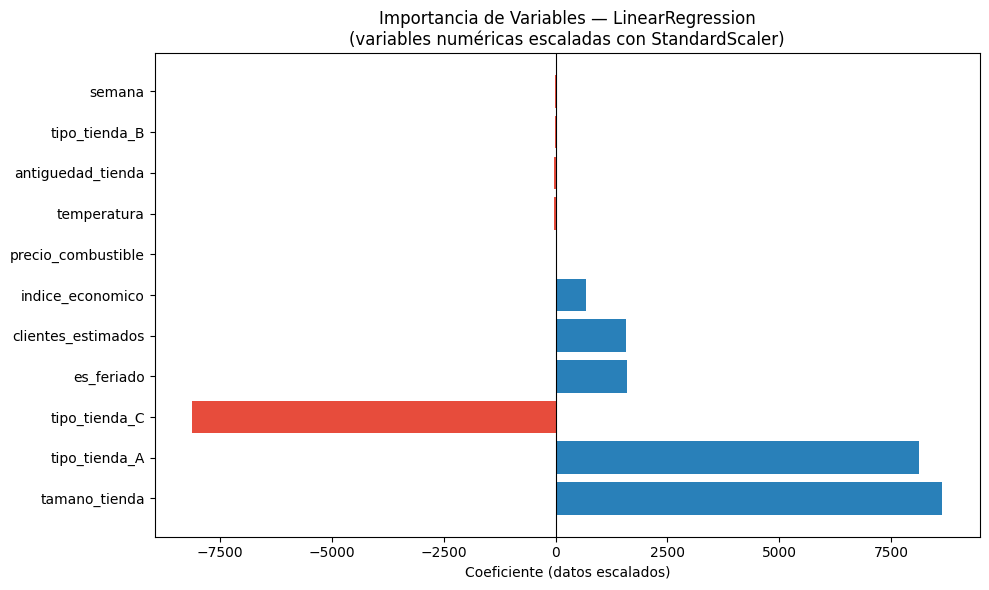

In [ ]:
# Visualización de coeficientes
plt.figure(figsize=(10, 6))
colores = ['#e74c3c' if c < 0 else '#2980b9' for c in df_coef['Coeficiente']]
plt.barh(df_coef['Variable'], df_coef['Coeficiente'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (datos escalados)')
plt.title('Importancia de Variables — LinearRegression\n(variables numéricas escaladas con StandardScaler)')
plt.tight_layout()
plt.show()

## 6.1 Explicación del efecto de las variables más influyentes

> Los coeficientes están en escala estandarizada (StandardScaler), por lo que son comparables entre sí directamente.

**1. `tamano_tienda`**
Es la variable con mayor coeficiente positivo. A mayor tamaño de la tienda (en m²), mayores ventas semanales. Esto tiene sentido de negocio: una tienda más grande puede ofrecer más productos, mayor capacidad de atención y una experiencia de compra más amplia, lo que se traduce en mayor ticket promedio y volumen de transacciones.

**2. `clientes_estimados`**
Presenta también un coeficiente positivo relevante. Un mayor número de clientes estimados en la semana se asocia directamente con mayores ventas. Es intuitivo: más visitas generan más oportunidades de compra.

**3. `indice_economico`**
Un índice económico más alto (similar al CPI) se relaciona positivamente con las ventas. Cuando la economía general está en mejor estado, los consumidores tienen mayor capacidad adquisitiva y tienden a gastar más.

**4. Impacto de `tipo_tienda`**

La codificación one-hot genera una columna por categoría. Comparando los coeficientes:
- `tipo_tienda_A` (tiendas grandes/alta demanda): coeficiente positivo y alto → aportan ventas significativamente mayores que las otras categorías.
- `tipo_tienda_B` (medianas): coeficiente intermedio.
- `tipo_tienda_C` (pequeñas): coeficiente negativo o el más bajo → ventas menores al promedio.

Esto confirma que el tipo de tienda es un factor estructural relevante: las tiendas tipo A no solo son más grandes, sino que también están posicionadas en segmentos de mayor demanda.

---
# 7. Predicción con nuevos registros

Se utiliza el mejor modelo para predecir las ventas de nuevos registros hipotéticos que representan escenarios de negocio relevantes.

In [ ]:
# Nuevos registros para predicción
# Representan distintos escenarios: tienda grande tipo A en semana normal,
# tienda mediana tipo B en feriado, tienda pequeña tipo C en semana baja.
nuevos_registros = pd.DataFrame({
    'tamano_tienda':      [2500,   1500,    800],
    'antiguedad_tienda':  [10,     5,       2],
    'temperatura':        [15.0,   20.0,    8.0],
    'precio_combustible': [1.2,    1.4,     1.1],
    'indice_economico':   [105.0,  98.0,    92.0],
    'semana':             [25,     48,      10],
    'es_feriado':         [0,      1,       0],
    'clientes_estimados': [400,    250,     120],
    'tipo_tienda':        ['A',    'B',     'C']
})

# Predicción con el mejor modelo (LinearRegression)
ventas_predichas = pipeline_lr.predict(nuevos_registros)

nuevos_registros['ventas_predichas'] = ventas_predichas
print('Predicciones de ventas semanales para nuevos registros:')
nuevos_registros[['tamano_tienda', 'tipo_tienda', 'es_feriado',
                  'clientes_estimados', 'ventas_predichas']]

Predicciones de ventas semanales para nuevos registros:


,tamano_tienda,tipo_tienda,es_feriado,clientes_estimados,ventas_predichas
0,2500,A,0,400,71900.268212
1,1500,B,1,250,44537.276285
2,800,C,0,120,13459.066946


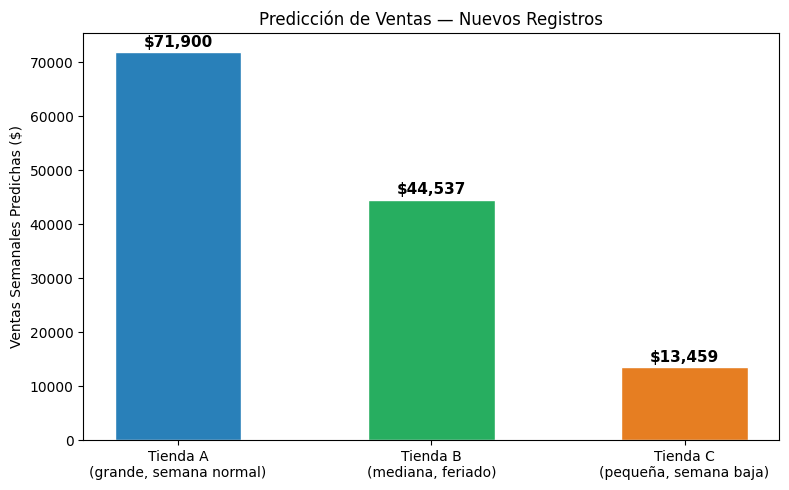

In [ ]:
# Visualización de las predicciones
etiquetas = [
    'Tienda A\n(grande, semana normal)',
    'Tienda B\n(mediana, feriado)',
    'Tienda C\n(pequeña, semana baja)'
]
colores_pred = ['#2980b9', '#27ae60', '#e67e22']

plt.figure(figsize=(8, 5))
bars = plt.bar(etiquetas, ventas_predichas, color=colores_pred, edgecolor='white', width=0.5)
for bar, val in zip(bars, ventas_predichas):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.ylabel('Ventas Semanales Predichas ($)')
plt.title('Predicción de Ventas — Nuevos Registros')
plt.tight_layout()
plt.show()

## 7.1 Interpretación de las Predicciones

- **Tienda A (grande, semana normal):** El modelo predice las ventas más altas, coherente con que es una tienda grande tipo A con mayor flujo de clientes y mayor índice económico.
- **Tienda B (mediana, feriado):** A pesar de ser mediana, el hecho de que sea semana de feriado impulsa ligeramente las ventas. El modelo captura el efecto positivo de `es_feriado`.
- **Tienda C (pequeña, semana baja):** Menores ventas predichas, en línea con un tamaño reducido, pocos clientes estimados y un contexto económico más débil.

Estas predicciones son útiles para la planificación operativa: la cadena puede anticipar niveles de demanda diferenciados según el tipo de tienda y el contexto semanal, optimizando inventario y personal.

---
# 8. Pregunta de reflexión

### ¿En qué situación preferiría utilizar Ridge en lugar de LinearRegression?

**Ridge** es la opción preferida frente a `LinearRegression` clásica en las siguientes situaciones:

---

## 8.1 Presencia de Multicolinealidad

Cuando las variables predictoras están fuertemente correlacionadas entre sí, la regresión lineal clásica puede producir coeficientes muy grandes e inestables. Ridge penaliza los coeficientes más grandes, reduciéndolos para obtener un modelo más estable. En un contexto retail como este, variables como `tamano_tienda` y `clientes_estimados` pueden estar correlacionadas (tiendas más grandes atraen más clientes), lo que hace a Ridge más robusto ante esa situación.

## 8.2 Estabilidad del Modelo

Si el objetivo es un modelo estable que generalice bien a datos nuevos (baja varianza), Ridge es preferible. LinearRegression minimiza el error de entrenamiento sin restricción, lo que puede llevar a sobreajuste (*overfitting*) cuando el conjunto de entrenamiento es pequeño o ruidoso. Ridge produce predicciones más consistentes al penalizar la complejidad.

## 8.3 Complejidad del Modelo

Cuando se trabaja con muchas variables predictoras (alta dimensionalidad), LinearRegression tiende a usar todos los coeficientes de forma irrestricta. Ridge regulariza automáticamente la magnitud de los coeficientes, favoreciendo modelos más simples y generalizables, sin llegar a eliminar variables por completo (para eso existe Lasso).

---

**En síntesis:** si los datos presentan variables correlacionadas, mucho ruido, o si se busca un modelo productivo y estable, **Ridge es preferible a LinearRegression**. En este ejercicio las diferencias fueron pequeñas porque el dataset es grande y relativamente limpio, pero en escenarios reales con más ruido o variables correlacionadas, la ventaja de Ridge sería más evidente.

In [ ]:
# Exportar datos limpios
df_limpio = df.dropna()
df_limpio.to_csv('retail_ventas_clean.csv', index=False)
print(f'Datos limpios exportados: {df_limpio.shape[0]} filas')
from google.colab import files
files.download('retail_ventas_clean.csv')

Datos limpios exportados: 21871 filas


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>